In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas版本:", pd.__version__)
print("numpy版本:", np.__version__)
print("环境OK,可以开始干活了!")

pandas版本: 2.3.3
numpy版本: 2.3.5
环境OK,可以开始干活了!


In [2]:
# 读取数据
# 注意:这个xlsx文件有两个sheet,分别是2009-2010年和2010-2011年的数据,我们都要读

df_1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# 把两年的数据拼起来
df = pd.concat([df_1, df_2], ignore_index=True)

print(f"数据读取完成!")
print(f"数据形状: {df.shape}")  # (行数, 列数)

数据读取完成!
数据形状: (1067371, 8)


In [5]:
# 数据里有几列pandas猜成了数字,但实际包含字母,我们强制转成字符串
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Customer ID'] = df['Customer ID'].astype(str)

# 保存数据。这次我们用csv格式,它简单稳定,不会有类型推断的问题
# (parquet快但严格,csv慢一点但宽容,对你现在的项目阶段csv足够了)
df.to_csv('online_retail_II.csv', index=False)
print("数据已保存为csv格式")
print(f"文件大小约: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

数据已保存为csv格式
文件大小约: 332.0 MB


In [6]:
# 看前5行
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
# 看数据的基本信息:每列的类型、有多少非空值
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  1067371 non-null  object        
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 65.1+ MB


In [8]:
# 看数值列的统计摘要(均值、最大、最小、分位数)
df.describe()

,Quantity,InvoiceDate,Price
count,1.067371e+06,1067371,1.067371e+06
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04
std,1.727058e+02,NaN,1.235531e+02


In [9]:
# 检查Customer ID里有多少是'nan'(也就是原本的空值)
nan_customers = (df['Customer ID'] == 'nan').sum()
total = len(df)
print(f"没有Customer ID的记录: {nan_customers:,} 条")
print(f"占总记录的: {nan_customers/total*100:.1f}%")

没有Customer ID的记录: 243,007 条
占总记录的: 22.8%


In [10]:
# 看看退货记录(Invoice以C开头)有多少
returns = df[df['Invoice'].str.startswith('C')]
print(f"退货记录: {len(returns):,} 条")
print(f"占总记录的: {len(returns)/len(df)*100:.1f}%")
print(f"\n退货记录的Quantity统计(应该都是负数):")
print(returns['Quantity'].describe())

退货记录: 19,494 条
占总记录的: 1.8%

退货记录的Quantity统计(应该都是负数):
count    19494.000000
mean       -25.186827
std        805.104908
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64


In [ ]:
#基于上面的发现,我们的清洗规则是:

# 删除 Customer ID 为 'nan' 的记录(22.8%)
# 删除退货记录(Invoice 以 C 开头,1.8%)
# 删除 Price ≤ 0 的记录(负价格、零价格都不合理)
# 删除 Quantity ≤ 0 的剩余记录(经过上面三步,理论上不应该还有,但保险起见)
# 暂时保留极端高值的记录,做完特征工程后再决定怎么处理

In [11]:
# 备份原始数据
df_raw = df.copy()
print(f"原始数据: {len(df_raw):,} 行")

原始数据: 1,067,371 行


In [12]:
# 数据清洗:按顺序应用规则,每步打印剩余行数

print(f"清洗前: {len(df):,} 行")

# 规则1: 删除没有Customer ID的记录
df = df[df['Customer ID'] != 'nan']
print(f"删除无Customer ID后: {len(df):,} 行")

# 规则2: 删除退货记录(Invoice以C开头)
df = df[~df['Invoice'].str.startswith('C')]
print(f"删除退货记录后: {len(df):,} 行")

# 规则3: 删除Price <= 0的记录
df = df[df['Price'] > 0]
print(f"删除非正Price后: {len(df):,} 行")

# 规则4: 删除Quantity <= 0的剩余记录(保险起见)
df = df[df['Quantity'] > 0]
print(f"删除非正Quantity后: {len(df):,} 行")

print(f"\n清洗完成。保留了原始数据的 {len(df)/len(df_raw)*100:.1f}%")

清洗前: 1,067,371 行
删除无Customer ID后: 824,364 行
删除退货记录后: 805,620 行
删除非正Price后: 805,549 行
删除非正Quantity后: 805,549 行

清洗完成。保留了原始数据的 75.5%


In [13]:
# 确认数据的时间范围
print(f"数据最早日期: {df['InvoiceDate'].min()}")
print(f"数据最晚日期: {df['InvoiceDate'].max()}")
print(f"总跨度: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} 天")

数据最早日期: 2009-12-01 07:45:00
数据最晚日期: 2011-12-09 12:50:00
总跨度: 738 天


In [14]:
# 定义观察期和预测期的分界线
import pandas as pd

# 我们把2011-06-01作为切分点
# 观察期: 2009-12-01 到 2011-05-31
# 预测期: 2011-06-01 到 2011-12-09
cutoff_date = pd.Timestamp('2011-06-01')

# 切分数据
df_observation = df[df['InvoiceDate'] < cutoff_date]
df_prediction = df[df['InvoiceDate'] >= cutoff_date]

print(f"观察期数据: {len(df_observation):,} 行")
print(f"观察期客户数: {df_observation['Customer ID'].nunique():,}")
print(f"观察期时间: {df_observation['InvoiceDate'].min()} 到 {df_observation['InvoiceDate'].max()}")

print(f"\n预测期数据: {len(df_prediction):,} 行")
print(f"预测期客户数: {df_prediction['Customer ID'].nunique():,}")
print(f"预测期时间: {df_prediction['InvoiceDate'].min()} 到 {df_prediction['InvoiceDate'].max()}")

观察期数据: 553,114 行
观察期客户数: 4,933
观察期时间: 2009-12-01 07:45:00 到 2011-05-31 15:41:00

预测期数据: 252,435 行
预测期客户数: 3,547
预测期时间: 2011-06-01 07:37:00 到 2011-12-09 12:50:00


In [15]:
# 获取观察期里所有客户的集合
customers_in_observation = set(df_observation['Customer ID'].unique())

# 获取预测期里出现过的客户的集合
customers_in_prediction = set(df_prediction['Customer ID'].unique())

# 流失客户 = 观察期出现过 但 预测期没出现过
churned_customers = customers_in_observation - customers_in_prediction
retained_customers = customers_in_observation & customers_in_prediction

# 构建标签:观察期里每个客户的churn状态
churn_labels = pd.DataFrame({
    'Customer ID': list(customers_in_observation),
    'churned': [1 if c in churned_customers else 0 for c in customers_in_observation]
})

print(f"观察期总客户数: {len(customers_in_observation):,}")
print(f"  ├── 流失客户: {len(churned_customers):,} ({len(churned_customers)/len(customers_in_observation)*100:.1f}%)")
print(f"  └── 留存客户: {len(retained_customers):,} ({len(retained_customers)/len(customers_in_observation)*100:.1f}%)")

观察期总客户数: 4,933
  ├── 流失客户: 2,331 (47.3%)
  └── 留存客户: 2,602 (52.7%)


In [16]:
# 我们要在观察期数据上计算RFM特征
# 先添加一列"销售额",= Quantity × Price
df_observation = df_observation.copy()  # 避免pandas警告
df_observation['Revenue'] = df_observation['Quantity'] * df_observation['Price']

# 观察期的"今天"是切分点(2011-06-01),用来计算Recency
reference_date = cutoff_date

print(f"参照日期(观察期结束): {reference_date}")
print(f"观察期总销售额: £{df_observation['Revenue'].sum():,.0f}")

参照日期(观察期结束): 2011-06-01 00:00:00
观察期总销售额: £12,164,595


In [17]:
# 按Customer ID分组,聚合计算RFM三个特征
rfm = df_observation.groupby('Customer ID').agg({
    # Recency: 最后一次购买距参照日期的天数
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    
    # Frequency: 客户下过多少张不同的发票(独立订单数)
    'Invoice': 'nunique',
    
    # Monetary: 总销售额
    'Revenue': 'sum'
}).reset_index()

# 给列重命名,让名字清晰
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM特征已计算完成,共 {len(rfm):,} 个客户")
print("\n前5个客户的RFM:")
print(rfm.head())
print("\nRFM的统计摘要:")
print(rfm.describe())

RFM特征已计算完成,共 4,933 个客户

前5个客户的RFM:
  Customer ID  Recency  Frequency  Monetary
0     12346.0      133         12  77556.46
1     12347.0       54          4   3146.75
2     12348.0       56          4   1709.40
3     12349.0      215          3   2671.14
4     12350.0      118          1    334.40

RFM的统计摘要:
           Recency    Frequency       Monetary
count  4933.000000  4933.000000    4933.000000
mean    168.707075     5.239408    2465.962951
std     141.932548    10.132239   10907.752454
min       0.000000     1.000000       2.900000
25%      43.000000     1.000000     317.600000
50%     161.000000     3.000000     774.870000
75%     243.000000     6.000000    2001.070000
max     546.000000   258.000000  413806.460000


In [18]:
# 把RFM特征和流失标签合并
data = rfm.merge(churn_labels, on='Customer ID')

print(f"合并后数据形状: {data.shape}")
print("\n前5行:")
print(data.head())

合并后数据形状: (4933, 5)

前5行:
  Customer ID  Recency  Frequency  Monetary  churned
0     12346.0      133         12  77556.46        1
1     12347.0       54          4   3146.75        0
2     12348.0       56          4   1709.40        0
3     12349.0      215          3   2671.14        0
4     12350.0      118          1    334.40        1


In [19]:
# 看看Monetary最高的10个客户
top_spenders = rfm.sort_values('Monetary', ascending=False).head(10)
print("销售额最高的10个客户:")
print(top_spenders)

print("\n下单次数最多的10个客户:")
top_frequent = rfm.sort_values('Frequency', ascending=False).head(10)
print(top_frequent)

销售额最高的10个客户:
     Customer ID  Recency  Frequency   Monetary
4779     18102.0       14        100  413806.46
1881     14646.0        5        103  359109.62
1459     14156.0       15        119  240473.97
2109     14911.0        5        258  190947.35
1080     13694.0        0        119  159642.54
4285     17511.0       14         44  120291.57
2236     15061.0       19        108  114007.30
4239     17450.0        0         19  108182.56
3592     16684.0       13         40  105565.15
590      13089.0        7        157   85851.97

下单次数最多的10个客户:
     Customer ID  Recency  Frequency   Monetary
2109     14911.0        5        258  190947.35
306      12748.0        0        213   32430.44
2452     15311.0        4        160   85669.95
590      13089.0        7        157   85851.97
4569     17850.0      180        155   56600.08
1846     14606.0        2        147   25486.17
4562     17841.0        0        134   41422.12
1459     14156.0       15        119  240473.97
1080     136

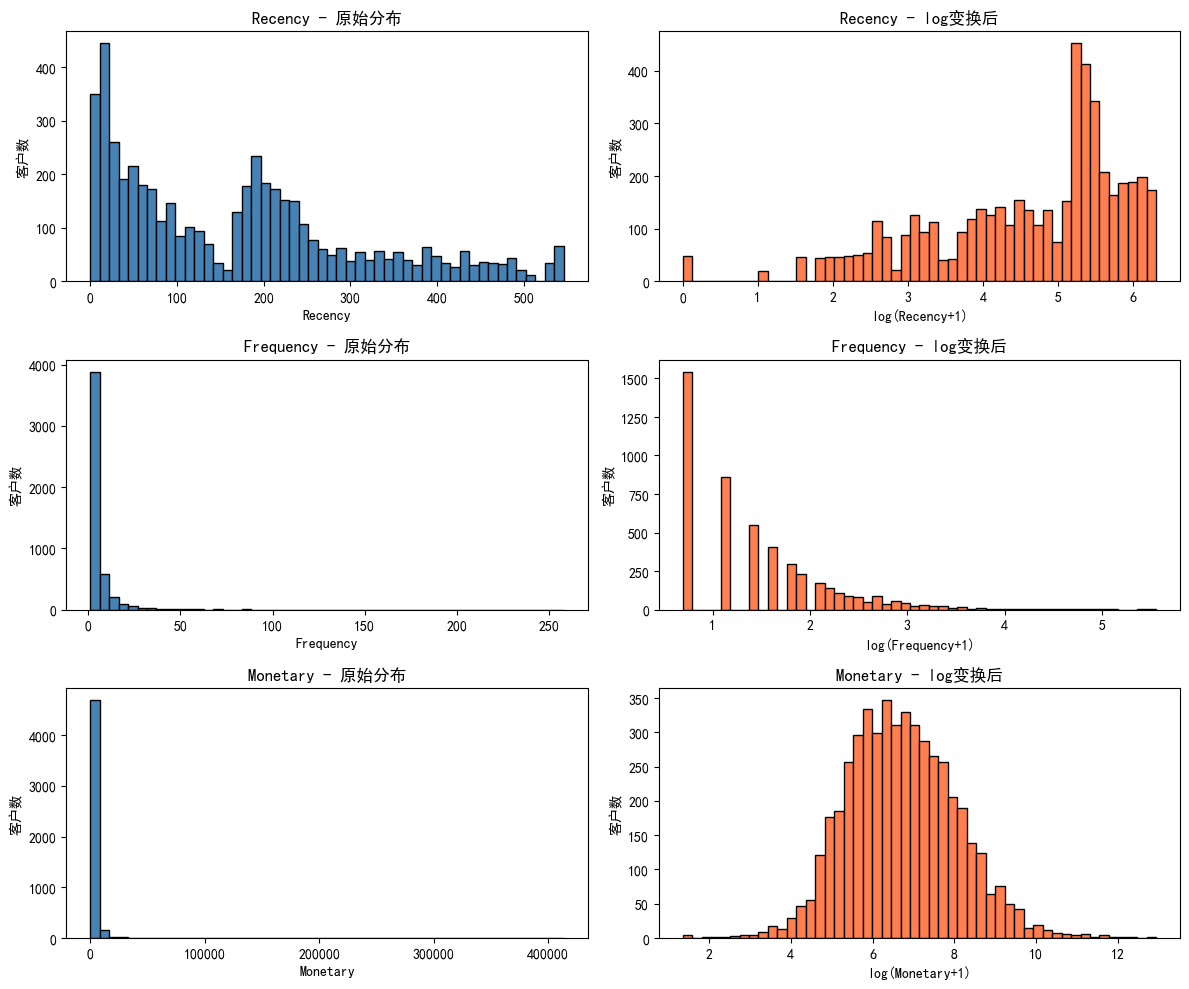

In [22]:
import matplotlib.pyplot as plt

# 创建3x2的子图布局,左边是原始分布,右边是log变换后的分布
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

features = ['Recency', 'Frequency', 'Monetary']
for i, feat in enumerate(features):
    # 左边:原始值的分布
    axes[i, 0].hist(rfm[feat], bins=50, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{feat} - 原始分布')
    axes[i, 0].set_xlabel(feat)
    axes[i, 0].set_ylabel('客户数')
    
    # 右边:log变换后的分布(+1是为了避免log(0))
    import numpy as np
    axes[i, 1].hist(np.log1p(rfm[feat]), bins=50, color='coral', edgecolor='black')
    axes[i, 1].set_title(f'{feat} - log变换后')
    axes[i, 1].set_xlabel(f'log({feat}+1)')
    axes[i, 1].set_ylabel('客户数')

plt.tight_layout()
plt.show()

In [21]:
# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("中文字体设置完成")

中文字体设置完成


In [23]:
# 创建log变换后的特征(保留原始特征做对比)
data['log_Frequency'] = np.log1p(data['Frequency'])
data['log_Monetary'] = np.log1p(data['Monetary'])

# Recency保持原值(双峰分布,不变换)

print("特征工程完成,当前data前5行:")
print(data.head())
print(f"\n当前特征列: {data.columns.tolist()}")

特征工程完成,当前data前5行:
  Customer ID  Recency  Frequency  Monetary  churned  log_Frequency  \
0     12346.0      133         12  77556.46        1       2.564949   
1     12347.0       54          4   3146.75        0       1.609438   
2     12348.0       56          4   1709.40        0       1.609438   
3     12349.0      215          3   2671.14        0       1.386294   
4     12350.0      118          1    334.40        1       0.693147   

   log_Monetary  
0     11.258774  
1      8.054443  
2      7.444483  
3      7.890635  
4      5.815324  

当前特征列: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'churned', 'log_Frequency', 'log_Monetary']


In [24]:
from sklearn.model_selection import train_test_split

# X = 特征,y = 目标
# 我们用Recency + log_Frequency + log_Monetary 三个特征
X = data[['Recency', 'log_Frequency', 'log_Monetary']]
y = data['churned']

print(f"特征矩阵X的形状: {X.shape}")
print(f"目标向量y的形状: {y.shape}")
print(f"\n流失客户比例: {y.mean():.2%}")

特征矩阵X的形状: (4933, 3)
目标向量y的形状: (4933,)

流失客户比例: 47.25%


In [26]:
# 80/20分割
# stratify=y 保证训练集和测试集的流失比例和原始数据一致(很重要)
# random_state=42 保证每次运行结果一致(可复现)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集: {X_train.shape[0]} 个客户")
print(f"测试集: {X_test.shape[0]} 个客户")
print(f"\n训练集流失率: {y_train.mean():.2%}")
print(f"测试集流失率: {y_test.mean():.2%}")

训练集: 3946 个客户
测试集: 987 个客户

训练集流失率: 47.26%
测试集流失率: 47.21%


In [27]:
from sklearn.preprocessing import StandardScaler

# 创建scaler(用训练集fit,然后变换两个集合)
scaler = StandardScaler()

# 重点:fit_transform只在训练集上做,测试集只用transform
# 这是防止数据泄露的关键步骤
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("标准化完成")
print(f"训练集特征均值(应该约为0): {X_train_scaled.mean(axis=0)}")
print(f"训练集特征标准差(应该约为1): {X_train_scaled.std(axis=0)}")

标准化完成
训练集特征均值(应该约为0): [-1.26046608e-17  2.41289221e-16  2.21481897e-16]
训练集特征标准差(应该约为1): [1. 1. 1.]


In [28]:
from sklearn.linear_model import LogisticRegression

# 创建模型
# random_state保证可复现
# max_iter=1000 给优化算法多一些迭代次数,防止不收敛警告
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# 训练模型(就这一行,fit就是"训练"的意思)
model_lr.fit(X_train_scaled, y_train)

print("逻辑回归模型训练完成!")

# 看看模型的系数(每个特征对流失的影响)
print(f"\n模型系数:")
for feat, coef in zip(X.columns, model_lr.coef_[0]):
    print(f"  {feat}: {coef:.4f}")
print(f"  截距: {model_lr.intercept_[0]:.4f}")

逻辑回归模型训练完成!

模型系数:
  Recency: 0.7260
  log_Frequency: -0.5438
  log_Monetary: -0.4281
  截距: -0.1724


In [29]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# 用训练好的模型预测测试集
y_pred = model_lr.predict(X_test_scaled)           # 预测的0/1标签
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]  # 预测为1(流失)的概率

# 计算各种指标
print("=" * 50)
print("逻辑回归模型 - 测试集表现")
print("=" * 50)
print(f"Accuracy(准确率):   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision(精确率):  {precision_score(y_test, y_pred):.4f}")
print(f"Recall(召回率):     {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:           {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_pred_proba):.4f}")

# 混淆矩阵:看预测错在哪里
print(f"\n混淆矩阵:")
cm = confusion_matrix(y_test, y_pred)
print(f"                  预测留存    预测流失")
print(f"实际留存(0):     {cm[0,0]:5d}        {cm[0,1]:5d}")
print(f"实际流失(1):     {cm[1,0]:5d}        {cm[1,1]:5d}")

# 详细报告
print(f"\n详细分类报告:")
print(classification_report(y_test, y_pred, target_names=['留存', '流失']))

逻辑回归模型 - 测试集表现
Accuracy(准确率):   0.7315
Precision(精确率):  0.7209
Recall(召回率):     0.7039
F1 Score:           0.7123
ROC-AUC:            0.7985

混淆矩阵:
                  预测留存    预测流失
实际留存(0):       394          127
实际流失(1):       138          328

详细分类报告:
              precision    recall  f1-score   support

          留存       0.74      0.76      0.75       521
          流失       0.72      0.70      0.71       466

    accuracy                           0.73       987
   macro avg       0.73      0.73      0.73       987
weighted avg       0.73      0.73      0.73       987



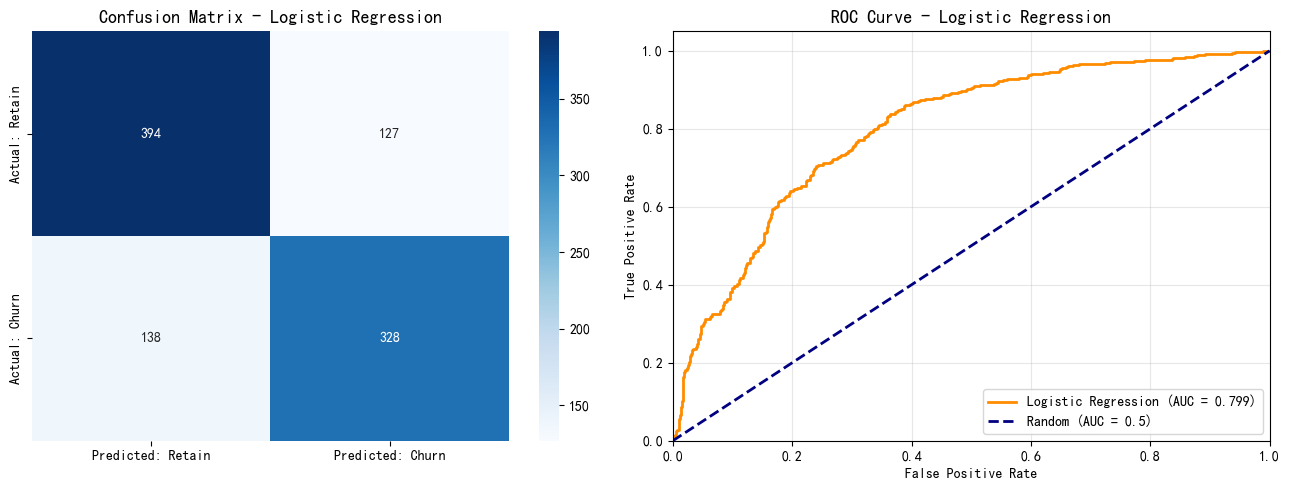

In [30]:
import seaborn as sns
from sklearn.metrics import roc_curve

# 图1:混淆矩阵可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图:混淆矩阵热图
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Retain', 'Predicted: Churn'],
            yticklabels=['Actual: Retain', 'Actual: Churn'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=13)

# 右图:ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression', fontsize=13)
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# 在notebook里直接安装XGBoost
# 前面的!是告诉Jupyter:这一行是bash命令,不是Python代码
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 7.9/101.7 MB 61.5 MB/s eta 0:00:02
   -------- ------------------------------- 22.8/101.7 MB 60.5 MB/s eta 0:00:02
   -------------- ------------------------- 35.9/101.7 MB 60.4 MB/s eta 0:00:02
   ------------------ --------------------- 48.2/101.7 MB 60.2 MB/s eta 0:00:01
   ----------------------- ---------------- 60.8/101.7 MB 60.1 MB/s eta 0:00:01
   ----------------------------- ---------- 73.9/101.7 MB 60.1 MB/s eta 0:00:01
   ---------------------------------- ----- 86.8/101.7 MB 60.1 MB/s eta 0:00:01
   ---------------------------------------  99.6/101.7 MB 60.1 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 60.1 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 53.7 MB/s  0:00:01


In [33]:
from xgboost import XGBClassifier

# 创建XGBoost分类器
# 我先用一组比较保守的参数(防止过拟合)
model_xgb = XGBClassifier(
    n_estimators=200,         # 用200棵树
    max_depth=4,              # 每棵树最多4层深(太深容易过拟合)
    learning_rate=0.1,        # 学习率
    random_state=42,
    eval_metric='logloss'
)

# 注意:XGBoost不需要标准化的特征,我们用原始的X_train就行
# (但我们用之前的X_train和X_test不变,只是不用scaled版本)
model_xgb.fit(X_train, y_train)

print("XGBoost模型训练完成!")

XGBoost模型训练完成!


In [34]:
# 预测
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

# 同样的指标体系
print("=" * 50)
print("XGBoost - 测试集表现")
print("=" * 50)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision:          {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:             {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:           {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# 混淆矩阵
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\n混淆矩阵:")
print(f"                  预测留存    预测流失")
print(f"实际留存(0):     {cm_xgb[0,0]:5d}        {cm_xgb[0,1]:5d}")
print(f"实际流失(1):     {cm_xgb[1,0]:5d}        {cm_xgb[1,1]:5d}")

# 直接对比!
print("\n" + "=" * 50)
print("对比表:Logistic Regression vs XGBoost")
print("=" * 50)
print(f"{'指标':<12} {'LR':<10} {'XGBoost':<10} {'提升':<10}")
print("-" * 42)
metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}
metrics_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}
for metric in metrics_lr:
    lr_val = metrics_lr[metric]
    xgb_val = metrics_xgb[metric]
    diff = xgb_val - lr_val
    sign = "+" if diff >= 0 else ""
    print(f"{metric:<12} {lr_val:<10.4f} {xgb_val:<10.4f} {sign}{diff:.4f}")

XGBoost - 测试集表现
Accuracy:           0.7102
Precision:          0.6974
Recall:             0.6824
F1 Score:           0.6898
ROC-AUC:            0.7935

混淆矩阵:
                  预测留存    预测流失
实际留存(0):       383          138
实际流失(1):       148          318

对比表:Logistic Regression vs XGBoost
指标           LR         XGBoost    提升        
------------------------------------------
Accuracy     0.7315     0.7102     -0.0213
Precision    0.7209     0.6974     -0.0235
Recall       0.7039     0.6824     -0.0215
F1           0.7123     0.6898     -0.0225
ROC-AUC      0.7985     0.7935     -0.0051


In [35]:
# 看XGBoost在训练集上的表现 vs 测试集
y_pred_train_xgb = model_xgb.predict(X_train)
y_pred_proba_train_xgb = model_xgb.predict_proba(X_train)[:, 1]

print("XGBoost - 训练集 vs 测试集 对比:")
print(f"{'指标':<12} {'训练集':<10} {'测试集':<10} {'差距':<10}")
print("-" * 42)
train_acc = accuracy_score(y_train, y_pred_train_xgb)
test_acc = accuracy_score(y_test, y_pred_xgb)
train_auc = roc_auc_score(y_train, y_pred_proba_train_xgb)
test_auc = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"{'Accuracy':<12} {train_acc:<10.4f} {test_acc:<10.4f} {train_acc-test_acc:<10.4f}")
print(f"{'ROC-AUC':<12} {train_auc:<10.4f} {test_auc:<10.4f} {train_auc-test_auc:<10.4f}")

print(f"\n如果差距很大(>0.05),说明过拟合")
print(f"如果差距小(<0.02),说明模型容量适中")

XGBoost - 训练集 vs 测试集 对比:
指标           训练集        测试集        差距        
------------------------------------------
Accuracy     0.7932     0.7102     0.0830    
ROC-AUC      0.8810     0.7935     0.0876    

如果差距很大(>0.05),说明过拟合
如果差距小(<0.02),说明模型容量适中


In [36]:
# 在观察期数据(df_observation)上,为每个客户计算更丰富的特征

# 先把观察期数据的辅助列准备好(部分前面有了,确保没问题)
df_obs = df_observation.copy()
df_obs['Revenue'] = df_obs['Quantity'] * df_obs['Price']

# 一次性算出多个特征
customer_features = df_obs.groupby('Customer ID').agg(
    # 经典RFM
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    
    # 新特征
    FirstPurchase=('InvoiceDate', 'min'),  # 第一次购买日期(暂存,后面要算tenure)
    LastPurchase=('InvoiceDate', 'max'),   # 最后一次购买日期(暂存)
    TotalQuantity=('Quantity', 'sum'),      # 累计购买件数
    UniqueProducts=('StockCode', 'nunique'),# 买过多少种商品(品类多样性)
    AvgPrice=('Price', 'mean'),             # 客户单品平均价格
    NumCountries=('Country', 'nunique'),    # 服务于多少个国家(B2B数据这个有信息)
).reset_index()

# 派生特征
customer_features['AvgOrderValue'] = customer_features['Monetary'] / customer_features['Frequency']

# CustomerTenure: 第一次到最后一次购买的天数(客户的"已知生命期")
customer_features['CustomerTenure'] = (
    customer_features['LastPurchase'] - customer_features['FirstPurchase']
).dt.days

# AvgDaysBetweenOrders: 平均订单间隔
# 对只下过1单的客户,这个值无意义,我们设为观察期总天数(意味着"没有重复购买")
observation_days = (df_obs['InvoiceDate'].max() - df_obs['InvoiceDate'].min()).days
customer_features['AvgDaysBetweenOrders'] = customer_features.apply(
    lambda row: row['CustomerTenure'] / (row['Frequency'] - 1) if row['Frequency'] > 1 else observation_days,
    axis=1
)

# 删除辅助列(日期对建模没用)
customer_features = customer_features.drop(columns=['FirstPurchase', 'LastPurchase'])

print(f"扩展后的特征矩阵形状: {customer_features.shape}")
print(f"\n所有特征列: {customer_features.columns.tolist()}")
print(f"\n前5行:")
print(customer_features.head())

扩展后的特征矩阵形状: (4933, 11)

所有特征列: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgPrice', 'NumCountries', 'AvgOrderValue', 'CustomerTenure', 'AvgDaysBetweenOrders']

前5行:
  Customer ID  Recency  Frequency  Monetary  TotalQuantity  UniqueProducts  \
0     12346.0      133         12  77556.46          74285              27   
1     12347.0       54          4   3146.75           1945              90   
2     12348.0       56          4   1709.40           2497              25   
3     12349.0      215          3   2671.14            993              90   
4     12350.0      118          1    334.40            197              17   

   AvgPrice  NumCountries  AvgOrderValue  CustomerTenure  AvgDaysBetweenOrders  
0  6.100000             1    6463.038333             400             36.363636  
1  2.503226             1     786.687500             157             52.333333  
2  3.137500             1     427.350000             189             63.00000

In [37]:
# 看看有多少客户Frequency=1(只下过1单)
only_one_order = (customer_features['Frequency'] == 1).sum()
total = len(customer_features)
print(f"只下过1单的客户: {only_one_order:,} 个 ({only_one_order/total*100:.1f}%)")
print(f"\n这些客户的流失率(预览):")
single_order_ids = customer_features[customer_features['Frequency']==1]['Customer ID'].tolist()
churn_in_single = churn_labels[churn_labels['Customer ID'].isin(single_order_ids)]['churned'].mean()
print(f"  {churn_in_single:.2%}")

print(f"\n下过多单的客户的流失率:")
multi_order_ids = customer_features[customer_features['Frequency']>1]['Customer ID'].tolist()
churn_in_multi = churn_labels[churn_labels['Customer ID'].isin(multi_order_ids)]['churned'].mean()
print(f"  {churn_in_multi:.2%}")

只下过1单的客户: 1,544 个 (31.3%)

这些客户的流失率(预览):
  73.58%

下过多单的客户的流失率:
  35.26%


In [38]:
# === 第1步:对偏态特征做log变换 ===
# 之前发现Frequency和Monetary右偏严重,现在新加的特征里也有几个可能偏态
# 我们对所有"非负且可能偏态"的特征都做log1p变换

skewed_features = ['Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 
                   'AvgPrice', 'AvgOrderValue', 'CustomerTenure', 'AvgDaysBetweenOrders']

for feat in skewed_features:
    customer_features[f'log_{feat}'] = np.log1p(customer_features[feat])

# === 第2步:合并标签 ===
data_v2 = customer_features.merge(churn_labels, on='Customer ID')

# === 第3步:选用于建模的特征 ===
# 用log版本的特征 + Recency(保持原值,因为是双峰分布) + NumCountries(原值,通常很小)
feature_cols = ['Recency', 'NumCountries',
                'log_Frequency', 'log_Monetary', 'log_TotalQuantity',
                'log_UniqueProducts', 'log_AvgPrice', 'log_AvgOrderValue',
                'log_CustomerTenure', 'log_AvgDaysBetweenOrders']

X = data_v2[feature_cols]
y = data_v2['churned']

print(f"特征数量: {len(feature_cols)}")
print(f"特征列表: {feature_cols}")

# === 第4步:重新分割 ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n训练集: {X_train.shape}, 测试集: {X_test.shape}")

特征数量: 10
特征列表: ['Recency', 'NumCountries', 'log_Frequency', 'log_Monetary', 'log_TotalQuantity', 'log_UniqueProducts', 'log_AvgPrice', 'log_AvgOrderValue', 'log_CustomerTenure', 'log_AvgDaysBetweenOrders']

训练集: (3946, 10), 测试集: (987, 10)


In [39]:
# 标准化(LR需要)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练LR
model_lr_v2 = LogisticRegression(random_state=42, max_iter=1000)
model_lr_v2.fit(X_train_scaled, y_train)

# 评估
y_pred_lr_v2 = model_lr_v2.predict(X_test_scaled)
y_pred_proba_lr_v2 = model_lr_v2.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("Logistic Regression v2 (10个特征)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_v2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_v2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_v2):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_lr_v2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr_v2):.4f}")

Logistic Regression v2 (10个特征)
Accuracy:  0.7315
Precision: 0.7199
Recall:    0.7060
F1:        0.7129
ROC-AUC:   0.7982


In [40]:
# XGBoost v2:多了7个特征,我们也调一下参数防过拟合
# 主要改动:增加正则化(reg_alpha, reg_lambda),保持深度不变
model_xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    reg_alpha=0.1,         # L1正则,惩罚过多特征
    reg_lambda=1.0,        # L2正则,惩罚过大的权重
    subsample=0.8,         # 每棵树只用80%的样本(防过拟合)
    colsample_bytree=0.8,  # 每棵树只用80%的特征(防过拟合)
    random_state=42,
    eval_metric='logloss'
)

# XGBoost不需要标准化,用原始X即可
model_xgb_v2.fit(X_train, y_train)

# 评估
y_pred_xgb_v2 = model_xgb_v2.predict(X_test)
y_pred_proba_xgb_v2 = model_xgb_v2.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBoost v2 (10个特征 + 正则化)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb_v2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_v2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb_v2):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_xgb_v2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb_v2):.4f}")

# 同时看训练集表现,检查过拟合
y_pred_proba_train_xgb_v2 = model_xgb_v2.predict_proba(X_train)[:, 1]
train_auc_v2 = roc_auc_score(y_train, y_pred_proba_train_xgb_v2)
test_auc_v2 = roc_auc_score(y_test, y_pred_proba_xgb_v2)
print(f"\n过拟合检查:")
print(f"  训练集AUC: {train_auc_v2:.4f}")
print(f"  测试集AUC: {test_auc_v2:.4f}")
print(f"  差距:      {train_auc_v2 - test_auc_v2:.4f}")

XGBoost v2 (10个特征 + 正则化)
Accuracy:  0.7092
Precision: 0.6868
Recall:    0.7060
F1:        0.6963
ROC-AUC:   0.7879

过拟合检查:
  训练集AUC: 0.9355
  测试集AUC: 0.7879
  差距:      0.1475


In [41]:
# 四个模型对比:LR v1 vs XGB v1 vs LR v2 vs XGB v2
print("=" * 75)
print("完整对比:基础特征 vs 扩展特征")
print("=" * 75)
print(f"{'指标':<12} {'LR v1':<10} {'XGB v1':<10} {'LR v2':<10} {'XGB v2':<10}")
print(f"{'(特征数)':<12} {'(3)':<10} {'(3)':<10} {'(10)':<10} {'(10)':<10}")
print("-" * 75)

results = {
    'LR v1':  {'Acc': accuracy_score(y_test, y_pred), 
               'Prec': precision_score(y_test, y_pred),
               'Rec': recall_score(y_test, y_pred),
               'F1': f1_score(y_test, y_pred),
               'AUC': roc_auc_score(y_test, y_pred_proba)},
    'XGB v1': {'Acc': accuracy_score(y_test, y_pred_xgb),
               'Prec': precision_score(y_test, y_pred_xgb),
               'Rec': recall_score(y_test, y_pred_xgb),
               'F1': f1_score(y_test, y_pred_xgb),
               'AUC': roc_auc_score(y_test, y_pred_proba_xgb)},
    'LR v2':  {'Acc': accuracy_score(y_test, y_pred_lr_v2),
               'Prec': precision_score(y_test, y_pred_lr_v2),
               'Rec': recall_score(y_test, y_pred_lr_v2),
               'F1': f1_score(y_test, y_pred_lr_v2),
               'AUC': roc_auc_score(y_test, y_pred_proba_lr_v2)},
    'XGB v2': {'Acc': accuracy_score(y_test, y_pred_xgb_v2),
               'Prec': precision_score(y_test, y_pred_xgb_v2),
               'Rec': recall_score(y_test, y_pred_xgb_v2),
               'F1': f1_score(y_test, y_pred_xgb_v2),
               'AUC': roc_auc_score(y_test, y_pred_proba_xgb_v2)},
}

for metric_name, metric_key in [('Accuracy', 'Acc'), ('Precision', 'Prec'),
                                  ('Recall', 'Rec'), ('F1', 'F1'), ('ROC-AUC', 'AUC')]:
    print(f"{metric_name:<12}", end="")
    for model_name in ['LR v1', 'XGB v1', 'LR v2', 'XGB v2']:
        print(f"{results[model_name][metric_key]:<10.4f}", end="")
    print()

完整对比:基础特征 vs 扩展特征
指标           LR v1      XGB v1     LR v2      XGB v2    
(特征数)        (3)        (3)        (10)       (10)      
---------------------------------------------------------------------------
Accuracy    0.7315    0.7102    0.7315    0.7092    
Precision   0.7209    0.6974    0.7199    0.6868    
Recall      0.7039    0.6824    0.7060    0.7060    
F1          0.7123    0.6898    0.7129    0.6963    
ROC-AUC     0.7985    0.7935    0.7982    0.7879    


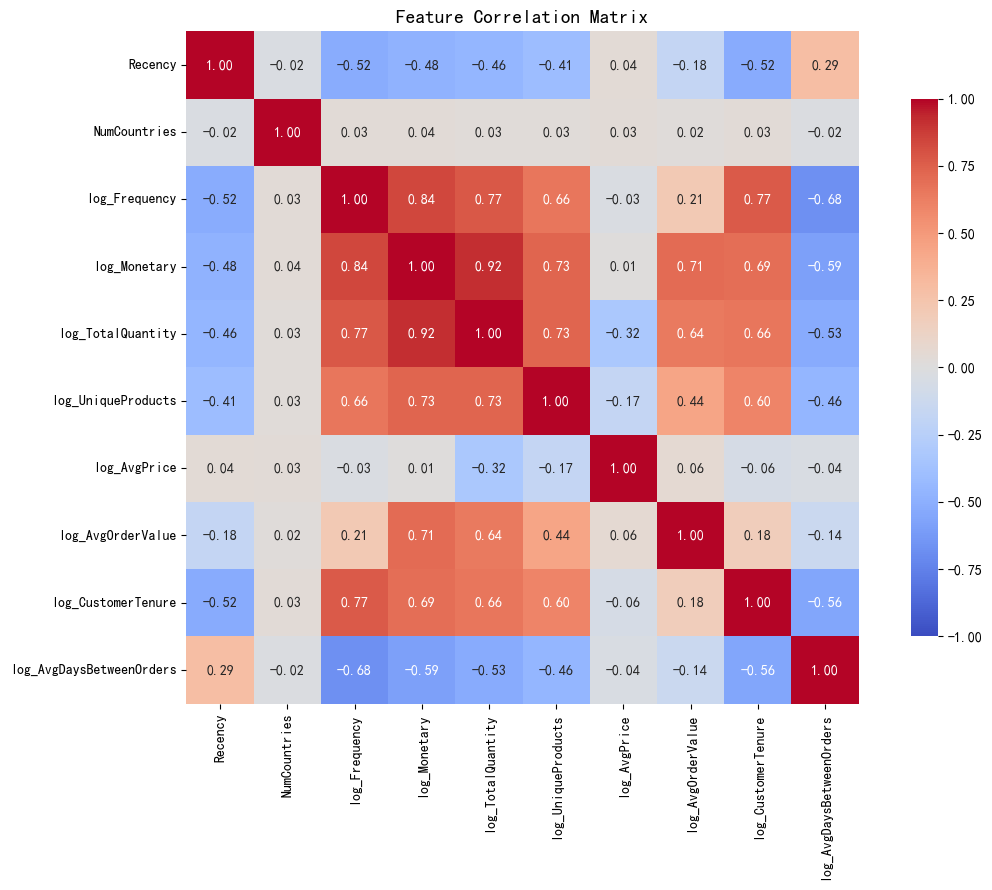


高度相关的特征对 (|相关系数| > 0.7):
  log_Monetary                 ↔ log_TotalQuantity            : +0.919
  log_Frequency                ↔ log_Monetary                 : +0.837
  log_Frequency                ↔ log_TotalQuantity            : +0.774
  log_Frequency                ↔ log_CustomerTenure           : +0.767
  log_TotalQuantity            ↔ log_UniqueProducts           : +0.734
  log_Monetary                 ↔ log_UniqueProducts           : +0.731
  log_Monetary                 ↔ log_AvgOrderValue            : +0.706


In [42]:
import seaborn as sns

# 计算所有特征之间的相关系数
corr_matrix = X.corr()

# 画热图
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# 找出高度相关的特征对
print("\n高度相关的特征对 (|相关系数| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

for f1, f2, c in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1:<28} ↔ {f2:<28} : {c:+.3f}")

In [43]:
# 决策:保留RFM(经典且独立信息源),加入NumCountries(完全独立),
# 加入log_AvgPrice(代表单价偏好,跟Monetary相关性低),
# 加入log_AvgDaysBetweenOrders(代表购买节奏,跟其他不冗余)

# 删除:log_TotalQuantity(和Monetary共线性0.92),
#       log_UniqueProducts(和Monetary、Frequency都高相关),
#       log_AvgOrderValue(和Monetary高相关),
#       log_CustomerTenure(和Frequency高相关)

feature_cols_lean = ['Recency', 'NumCountries',
                     'log_Frequency', 'log_Monetary', 
                     'log_AvgPrice', 'log_AvgDaysBetweenOrders']

print(f"精简后特征数: {len(feature_cols_lean)}")
print(f"特征列表: {feature_cols_lean}")

# 验证一下:精简后的特征相关性
X_lean = data_v2[feature_cols_lean]
print(f"\n精简后特征间最高相关性:")
corr_lean = X_lean.corr()
max_corr = 0
max_pair = None
for i in range(len(corr_lean.columns)):
    for j in range(i+1, len(corr_lean.columns)):
        c = abs(corr_lean.iloc[i, j])
        if c > max_corr:
            max_corr = c
            max_pair = (corr_lean.columns[i], corr_lean.columns[j], corr_lean.iloc[i, j])
print(f"  {max_pair[0]} ↔ {max_pair[1]}: {max_pair[2]:+.3f}")

精简后特征数: 6
特征列表: ['Recency', 'NumCountries', 'log_Frequency', 'log_Monetary', 'log_AvgPrice', 'log_AvgDaysBetweenOrders']

精简后特征间最高相关性:
  log_Frequency ↔ log_Monetary: +0.837


In [44]:
# 重新分割数据
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lean, y, test_size=0.2, random_state=42, stratify=y
)

# === LR (精简版) ===
scaler_l = StandardScaler()
X_train_l_scaled = scaler_l.fit_transform(X_train_l)
X_test_l_scaled = scaler_l.transform(X_test_l)

model_lr_lean = LogisticRegression(random_state=42, max_iter=1000)
model_lr_lean.fit(X_train_l_scaled, y_train_l)

y_pred_lr_lean = model_lr_lean.predict(X_test_l_scaled)
y_pred_proba_lr_lean = model_lr_lean.predict_proba(X_test_l_scaled)[:, 1]

# === XGBoost (精简版) ===
model_xgb_lean = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss'
)
model_xgb_lean.fit(X_train_l, y_train_l)

y_pred_xgb_lean = model_xgb_lean.predict(X_test_l)
y_pred_proba_xgb_lean = model_xgb_lean.predict_proba(X_test_l)[:, 1]

# === 看XGBoost是否还过拟合 ===
y_pred_proba_train_xgb_lean = model_xgb_lean.predict_proba(X_train_l)[:, 1]
train_auc_lean = roc_auc_score(y_train_l, y_pred_proba_train_xgb_lean)
test_auc_lean = roc_auc_score(y_test_l, y_pred_proba_xgb_lean)

# === 5个模型大对比 ===
print("=" * 90)
print("5个模型完整对比")
print("=" * 90)
print(f"{'指标':<12} {'LR v1':<10} {'XGB v1':<10} {'LR v2':<10} {'XGB v2':<10} {'LR lean':<10} {'XGB lean':<10}")
print(f"{'(特征数)':<12} {'(3)':<10} {'(3)':<10} {'(10)':<10} {'(10)':<10} {'(6)':<10} {'(6)':<10}")
print("-" * 90)

all_results = {
    'LR v1':    (y_test, y_pred, y_pred_proba),
    'XGB v1':   (y_test, y_pred_xgb, y_pred_proba_xgb),
    'LR v2':    (y_test, y_pred_lr_v2, y_pred_proba_lr_v2),
    'XGB v2':   (y_test, y_pred_xgb_v2, y_pred_proba_xgb_v2),
    'LR lean':  (y_test_l, y_pred_lr_lean, y_pred_proba_lr_lean),
    'XGB lean': (y_test_l, y_pred_xgb_lean, y_pred_proba_xgb_lean),
}

for metric_name, metric_fn, needs_proba in [
    ('Accuracy', accuracy_score, False),
    ('Precision', precision_score, False),
    ('Recall', recall_score, False),
    ('F1', f1_score, False),
    ('ROC-AUC', roc_auc_score, True)
]:
    print(f"{metric_name:<12}", end="")
    for model_name in ['LR v1', 'XGB v1', 'LR v2', 'XGB v2', 'LR lean', 'XGB lean']:
        y_true, y_p, y_pp = all_results[model_name]
        score = metric_fn(y_true, y_pp if needs_proba else y_p)
        print(f"{score:<10.4f}", end="")
    print()

print(f"\nXGBoost lean 过拟合检查:")
print(f"  训练集AUC: {train_auc_lean:.4f}")
print(f"  测试集AUC: {test_auc_lean:.4f}")
print(f"  差距:      {train_auc_lean - test_auc_lean:.4f}")

5个模型完整对比
指标           LR v1      XGB v1     LR v2      XGB v2     LR lean    XGB lean  
(特征数)        (3)        (3)        (10)       (10)       (6)        (6)       
------------------------------------------------------------------------------------------
Accuracy    0.7315    0.7102    0.7315    0.7092    0.7295    0.7072    
Precision   0.7209    0.6974    0.7199    0.6868    0.7206    0.6895    
Recall      0.7039    0.6824    0.7060    0.7060    0.6974    0.6910    
F1          0.7123    0.6898    0.7129    0.6963    0.7088    0.6902    
ROC-AUC     0.7985    0.7935    0.7982    0.7879    0.7989    0.7949    

XGBoost lean 过拟合检查:
  训练集AUC: 0.9130
  测试集AUC: 0.7949
  差距:      0.1181


In [45]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 8.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [47]:
import shap

# 用LR lean模型做SHAP分析
# SHAP需要看scaled的数据(因为LR模型是在scaled数据上训练的)

# 创建explainer (LinearExplainer专门用于线性模型,快而准)
explainer = shap.LinearExplainer(model_lr_lean, X_train_l_scaled)

# 计算测试集上每个样本、每个特征的SHAP值
shap_values = explainer.shap_values(X_test_l_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print(f"(意思:{shap_values.shape[0]}个测试样本 × {shap_values.shape[1]}个特征)")

SHAP values shape: (987, 6)
(意思:987个测试样本 × 6个特征)


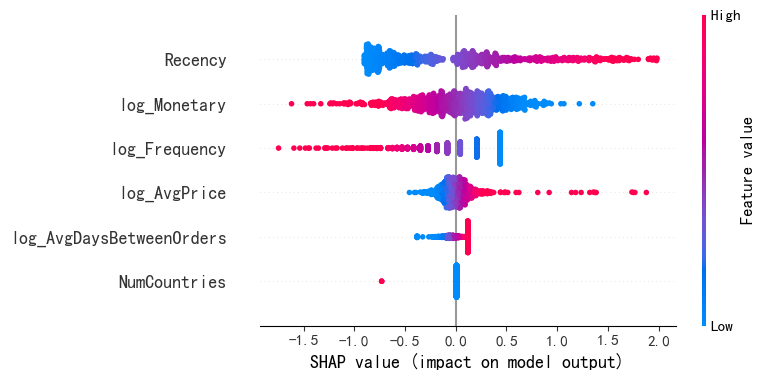

In [48]:
# 全局 SHAP summary plot
# 这张图告诉我们:每个特征对模型预测的总体影响
shap.summary_plot(shap_values, X_test_l, feature_names=feature_cols_lean, show=True)

XGBoost给每个特征的重要性评分:
                    feature  importance
2             log_Frequency    0.304750
0                   Recency    0.270347
3              log_Monetary    0.176257
5  log_AvgDaysBetweenOrders    0.147194
4              log_AvgPrice    0.101452
1              NumCountries    0.000000


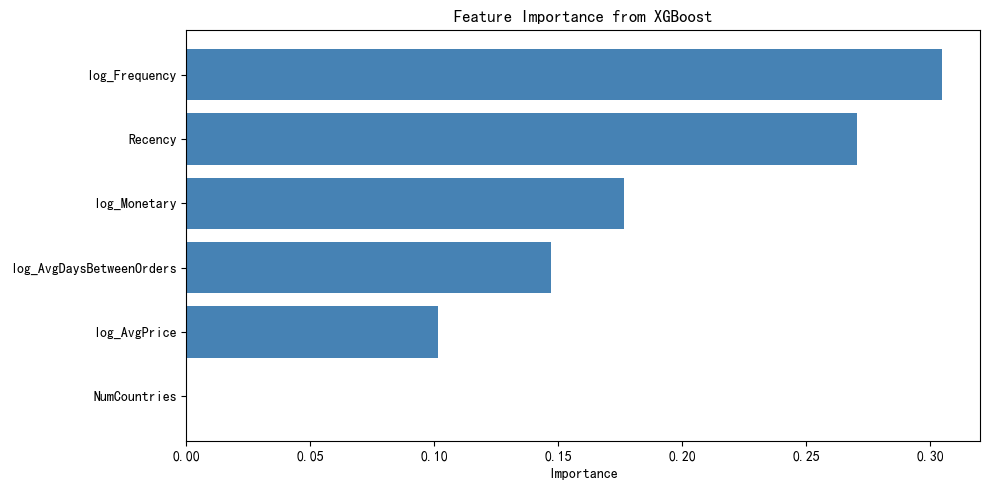

In [49]:
# 用XGBoost lean的feature_importances_(这是XGBoost自动计算的)
# 它衡量每个特征在所有决策树里被用了多少次、贡献了多少

import pandas as pd

xgb_importance = pd.DataFrame({
    'feature': X_lean.columns,
    'importance': model_xgb_lean.feature_importances_
}).sort_values('importance', ascending=False)

print("XGBoost给每个特征的重要性评分:")
print(xgb_importance)

# 可视化
plt.figure(figsize=(10, 5))
plt.barh(xgb_importance['feature'], xgb_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance from XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
# 找一个"高风险流失"客户和一个"安全留存"客户,看每个特征怎么贡献的

# 拿到所有测试客户的预测概率
test_probs = model_lr_lean.predict_proba(X_test_l_scaled)[:, 1]

# 找一个预测流失概率最高的客户
high_risk_idx = np.argmax(test_probs)
low_risk_idx = np.argmin(test_probs)

print(f"高风险客户 (索引{high_risk_idx}): 预测流失概率 = {test_probs[high_risk_idx]:.2%}")
print(f"低风险客户 (索引{low_risk_idx}): 预测流失概率 = {test_probs[low_risk_idx]:.2%}")

# 看他们的原始特征值
print(f"\n高风险客户的特征值:")
print(X_test_l.iloc[high_risk_idx])
print(f"\n低风险客户的特征值:")
print(X_test_l.iloc[low_risk_idx])

高风险客户 (索引705): 预测流失概率 = 98.35%
低风险客户 (索引742): 预测流失概率 = 1.32%

高风险客户的特征值:
Recency                     490.000000
NumCountries                  1.000000
log_Frequency                 0.693147
log_Monetary                  4.869302
log_AvgPrice                  4.869302
log_AvgDaysBetweenOrders      6.304449
Name: 163, dtype: float64

低风险客户的特征值:
Recency                     27.000000
NumCountries                 1.000000
log_Frequency                4.174387
log_Monetary                11.104609
log_AvgPrice                 0.947343
log_AvgDaysBetweenOrders     2.204254
Name: 1587, dtype: float64


高风险客户的SHAP分解(预测流失概率: 98.35%)


C:\Users\qinpe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


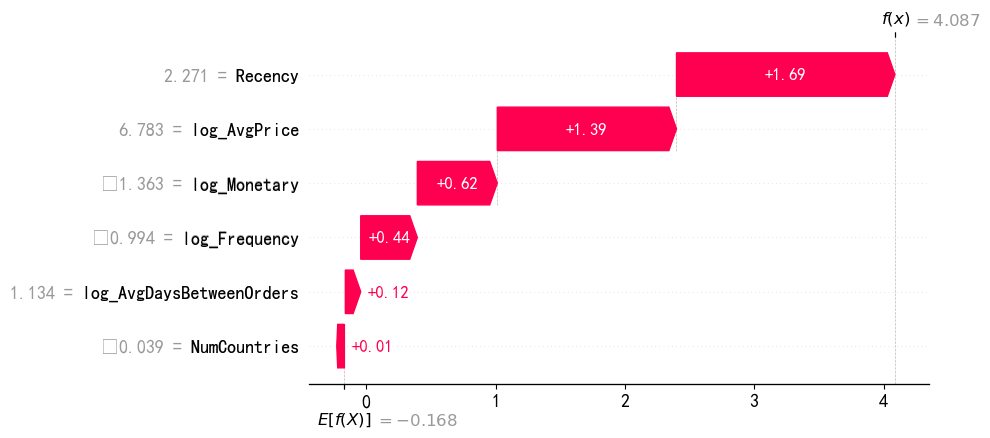

In [51]:
# 画高风险客户的SHAP waterfall plot
print("=" * 50)
print(f"高风险客户的SHAP分解(预测流失概率: {test_probs[high_risk_idx]:.2%})")
print("=" * 50)

shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_l_scaled[high_risk_idx],
    feature_names=feature_cols_lean
), show=True)

In [52]:
import joblib
import os

# 创建一个文件夹来存放模型相关的文件
os.makedirs('app_files', exist_ok=True)

# 保存LR模型(我们的最终冠军)
joblib.dump(model_lr_lean, 'app_files/model.pkl')

# 保存scaler(因为我们的特征是标准化过的,部署时也需要做同样的变换)
joblib.dump(scaler_l, 'app_files/scaler.pkl')

# 保存SHAP explainer(用于解释预测)
joblib.dump(explainer, 'app_files/explainer.pkl')

# 保存特征列表(确保app里特征顺序跟训练时一致)
joblib.dump(feature_cols_lean, 'app_files/feature_cols.pkl')

# 同时保存训练集的统计信息,app里需要用来给用户输入合理的默认值
train_stats = {
    'Recency': {'min': X_train_l['Recency'].min(), 
                'max': X_train_l['Recency'].max(),
                'median': X_train_l['Recency'].median()},
    'Frequency_original': {'min': 1, 'max': 200, 'median': 3},
    'Monetary_original': {'min': 1, 'max': 50000, 'median': 775},
    'AvgPrice_original': {'min': 0.5, 'max': 50, 'median': 3},
    'AvgDaysBetween_original': {'min': 1, 'max': 546, 'median': 30},
}
joblib.dump(train_stats, 'app_files/train_stats.pkl')

print("✅ 所有文件已保存到 app_files/ 文件夹")
print("\n文件列表:")
for f in os.listdir('app_files'):
    size_kb = os.path.getsize(f'app_files/{f}') / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

✅ 所有文件已保存到 app_files/ 文件夹

文件列表:
  explainer.pkl (12.0 KB)
  feature_cols.pkl (0.1 KB)
  model.pkl (0.9 KB)
  scaler.pkl (1.1 KB)
  train_stats.pkl (0.2 KB)


In [53]:
!pip install streamlit

In [54]:
app_code = '''
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# 配置:页面标题和图标
# ============================================================
st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="🛒",
    layout="wide"
)

# ============================================================
# 加载所有保存的模型文件(用 @st.cache_resource 避免每次重跑)
# ============================================================
@st.cache_resource
def load_artifacts():
    model = joblib.load('app_files/model.pkl')
    scaler = joblib.load('app_files/scaler.pkl')
    explainer = joblib.load('app_files/explainer.pkl')
    feature_cols = joblib.load('app_files/feature_cols.pkl')
    train_stats = joblib.load('app_files/train_stats.pkl')
    return model, scaler, explainer, feature_cols, train_stats

model, scaler, explainer, feature_cols, train_stats = load_artifacts()

# ============================================================
# 页面标题和介绍
# ============================================================
st.title("🛒 E-commerce Customer Churn Predictor")
st.markdown("""
This app predicts the probability that a B2B retail customer will **churn** 
(stop ordering in the next 6 months) based on their purchase behavior.

**Model:** Logistic Regression trained on UCI Online Retail II dataset (1M+ transactions).
""")

st.divider()

# ============================================================
# 输入区:用sidebar(侧边栏)收集用户输入
# ============================================================
st.sidebar.header("📊 Customer Profile Input")
st.sidebar.markdown("Enter the customer's behavioral metrics:")

# Recency
recency = st.sidebar.slider(
    "Recency (days since last purchase)",
    min_value=0, max_value=546, value=60,
    help="How many days ago was their most recent order?"
)

# Frequency  
frequency = st.sidebar.slider(
    "Frequency (number of unique orders)",
    min_value=1, max_value=200, value=3,
    help="How many separate orders has this customer placed?"
)

# Monetary
monetary = st.sidebar.number_input(
    "Monetary (total spend in £)",
    min_value=1.0, max_value=500000.0, value=775.0, step=10.0,
    help="Total amount spent across all orders"
)

# Average Price
avg_price = st.sidebar.number_input(
    "Average Item Price (£)",
    min_value=0.1, max_value=200.0, value=3.0, step=0.1,
    help="Average price per item purchased"
)

# Avg days between orders
avg_days = st.sidebar.slider(
    "Avg days between orders",
    min_value=1, max_value=546, value=30,
    help="Average gap between consecutive orders (high if only one order)"
)

# NumCountries
num_countries = st.sidebar.selectbox(
    "Number of countries served",
    options=[1, 2, 3, 4, 5],
    index=0
)

# 预测按钮
predict_button = st.sidebar.button("🔮 Predict Churn Risk", type="primary", use_container_width=True)

# ============================================================
# 预测区:点击按钮后显示结果
# ============================================================
if predict_button:
    # 构造特征向量(顺序要和训练时一致!)
    raw_features = {
        'Recency': recency,
        'NumCountries': num_countries,
        'log_Frequency': np.log1p(frequency),
        'log_Monetary': np.log1p(monetary),
        'log_AvgPrice': np.log1p(avg_price),
        'log_AvgDaysBetweenOrders': np.log1p(avg_days)
    }
    X_input = pd.DataFrame([raw_features])[feature_cols]
    
    # 标准化(必须用训练时的scaler)
    X_input_scaled = scaler.transform(X_input)
    
    # 预测
    churn_proba = model.predict_proba(X_input_scaled)[0, 1]
    churn_pred = "🚨 High Churn Risk" if churn_proba > 0.5 else "✅ Likely to Retain"
    
    # ===== 左右两列布局 =====
    col1, col2 = st.columns([1, 1])
    
    with col1:
        st.subheader("Prediction Result")
        st.metric(
            label="Churn Probability",
            value=f"{churn_proba:.1%}",
            delta=churn_pred,
            delta_color="inverse" if churn_proba > 0.5 else "normal"
        )
        
        # 概率条
        st.progress(churn_proba)
        
        # 解读
        if churn_proba > 0.7:
            st.error("⚠️ Very high churn risk. Recommend immediate retention intervention.")
        elif churn_proba > 0.5:
            st.warning("⚠️ Moderate-to-high churn risk. Consider engagement campaign.")
        elif churn_proba > 0.3:
            st.info("ℹ️ Low-to-moderate churn risk. Monitor activity.")
        else:
            st.success("✅ Low churn risk. Customer appears engaged.")
    
    with col2:
        st.subheader("Customer Snapshot")
        snapshot_df = pd.DataFrame({
            'Metric': ['Recency', 'Frequency', 'Total Spend', 'Avg Item Price', 'Avg Days Between Orders', 'Countries'],
            'Value': [f"{recency} days", f"{frequency} orders", f"£{monetary:,.0f}", 
                      f"£{avg_price:.2f}", f"{avg_days} days", f"{num_countries}"]
        })
        st.dataframe(snapshot_df, hide_index=True, use_container_width=True)
    
    st.divider()
    
    # ===== SHAP 解释 =====
    st.subheader("📊 Why this prediction? (SHAP Explanation)")
    st.markdown("Each feature contributes to pushing the prediction higher (churn) or lower (retain).")
    
    shap_values = explainer.shap_values(X_input_scaled)
    
    # 画 waterfall plot
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_input_scaled[0],
            feature_names=feature_cols
        ),
        show=False
    )
    st.pyplot(fig, use_container_width=True)
    plt.close()
    
    st.caption("💡 Red bars push the prediction toward churn; blue bars push toward retention.")

else:
    # 没点按钮时显示一些项目说明
    st.info("👈 Enter customer profile in the sidebar and click **Predict** to see the result.")
    
    with st.expander("📖 About this project"):
        st.markdown("""
        **Dataset:** UCI Online Retail II — 1M+ transactions from a UK-based gift retailer (2009-2011)
        
        **Methodology:**
        - **Time-based split:** observation period (2009-12 to 2011-05), prediction period (2011-06 to 2011-12)
        - **Churn definition:** customer made no purchases during the 6-month prediction period
        - **Features:** RFM + behavioral indicators (AvgPrice, OrderInterval)
        - **Models compared:** Logistic Regression vs XGBoost (6 versions)
        - **Final model:** Logistic Regression (AUC 0.80) — chosen for simplicity, interpretability, and equivalent performance
        
        **Key business insights:**
        - **First-purchase customers churn at 73%** vs 35% for repeat buyers — the "second purchase" is the critical milestone
        - **High average item price correlates with higher churn** — likely one-time gift buyers
        - **Recency is the strongest predictor** — more important than total spend
        """)
    
    with st.expander("🛠️ Tech stack"):
        st.markdown("""
        - **Data processing:** pandas, numpy
        - **Modeling:** scikit-learn, XGBoost
        - **Interpretability:** SHAP
        - **Deployment:** Streamlit
        """)

# ============================================================
# 页脚
# ============================================================
st.divider()
st.caption("Built with Streamlit | Model: Logistic Regression | Dataset: UCI Online Retail II")
'''

# 把代码写入app.py
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py 创建成功!")
print(f"文件大小: {len(app_code)} 字符")

✅ app.py 创建成功!
文件大小: 7353 字符


In [55]:
import os

print("项目目录文件列表:")
for f in sorted(os.listdir('.')):
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1024
        print(f"  {f} ({size:.1f} KB)")
    else:
        print(f"  📁 {f}/")

项目目录文件列表:
  📁 .ipynb_checkpoints/
  01_data_exploration.ipynb (529.1 KB)
  app.py (7.7 KB)
  📁 app_files/
  online_retail_II.csv (94381.4 KB)
  online_retail_II.xlsx (44553.0 KB)


In [56]:
import os

print("=" * 60)
print("📦 准备上传的文件清单")
print("=" * 60)

# 需要上传的文件/文件夹
files_to_upload = {
    '✅ app.py': 'Streamlit应用代码',
    '✅ app_files/': '保存的模型文件(必需)',
    '✅ 01_data_exploration.ipynb': '你的分析notebook',
}

# 不要上传的文件
files_to_skip = {
    '❌ online_retail_II.xlsx': '原始数据,太大 (45MB)',
    '❌ online_retail_II.csv': '清洗后的数据,太大 (60MB+)',
    '❌ .ipynb_checkpoints/': 'Jupyter自动备份,无用',
}

print("\n要上传的文件:")
for f, desc in files_to_upload.items():
    print(f"  {f:<35} — {desc}")

print("\n不要上传的文件:")
for f, desc in files_to_skip.items():
    print(f"  {f:<35} — {desc}")

# 检查实际文件大小
print("\n" + "=" * 60)
print("📊 实际文件大小检查:")
print("=" * 60)
for f in sorted(os.listdir('.')):
    if os.path.isfile(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        flag = "⚠️ 太大" if size_mb > 10 else "✅"
        print(f"  {flag} {f}: {size_mb:.2f} MB")
    elif os.path.isdir(f) and f not in ['.ipynb_checkpoints', '__pycache__']:
        total_size = 0
        for root, dirs, files in os.walk(f):
            for file in files:
                total_size += os.path.getsize(os.path.join(root, file))
        size_mb = total_size / (1024 * 1024)
        print(f"  📁 {f}/: {size_mb:.2f} MB")

📦 准备上传的文件清单

要上传的文件:
  ✅ app.py                            — Streamlit应用代码
  ✅ app_files/                        — 保存的模型文件(必需)
  ✅ 01_data_exploration.ipynb         — 你的分析notebook

不要上传的文件:
  ❌ online_retail_II.xlsx             — 原始数据,太大 (45MB)
  ❌ online_retail_II.csv              — 清洗后的数据,太大 (60MB+)
  ❌ .ipynb_checkpoints/               — Jupyter自动备份,无用

📊 实际文件大小检查:
  ✅ 01_data_exploration.ipynb: 0.53 MB
  ✅ app.py: 0.01 MB
  📁 app_files/: 0.01 MB
  ⚠️ 太大 online_retail_II.csv: 92.17 MB
  ⚠️ 太大 online_retail_II.xlsx: 43.51 MB


In [58]:
readme_content = '''# 🛒 E-commerce Customer Churn Prediction

End-to-end machine learning project predicting customer churn for a UK-based B2B gift retailer, with interactive Streamlit deployment.

**🚀 [Live Demo](https://your-app-url.streamlit.app)** *(deployment in progress)*

---

## 📊 Project Overview

**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — 1M+ transactions from 2009-2011

**Business question:** Which customers are likely to stop ordering in the next 6 months?

**Approach:**
- Time-based train/test split (observation: 2009-12 to 2011-05, prediction: 2011-06 to 2011-12)
- Churn definition: customer made no purchases during the 6-month prediction period
- Feature engineering: RFM + behavioral indicators (AvgPrice, OrderInterval)
- Model comparison across 6 versions (Logistic Regression vs XGBoost with various feature sets)
- Model interpretation with SHAP (global and local)
- Streamlit web app for interactive predictions

---

## 🎯 Key Results

| Model | Features | Test ROC-AUC | Notes |
|-------|----------|--------------|-------|
| Logistic Regression v1 | 3 (RFM only) | **0.7985** | Final production model |
| XGBoost v1 | 3 (RFM only) | 0.7935 | Slight overfitting |
| Logistic Regression v2 | 10 (full feature set) | 0.7982 | No gain from extra features |
| XGBoost v2 | 10 (regularized) | 0.7879 | Multicollinearity hurt performance |

**Final model: Logistic Regression** — selected for equivalent performance with superior interpretability and simplicity.

---

## 💡 Business Insights

1. **The "Second Purchase" Effect**: First-time customers churn at **73%** vs **35%** for repeat buyers. Operational priority: convert first-time buyers to repeat buyers.

2. **Counterintuitive AvgPrice Pattern**: High average item price correlates with **higher** churn risk — likely one-time gift buyers without retention incentive.

3. **Recency Dominates**: Recency is the strongest churn predictor (~1.7x more important than Monetary), confirming the importance of recent engagement over absolute spend.

---

## 🛠️ Tech Stack

- **Data Processing**: pandas, numpy
- **Modeling**: scikit-learn (Logistic Regression), XGBoost
- **Interpretability**: SHAP
- **Deployment**: Streamlit
- **Visualization**: matplotlib, seaborn

---

## 📁 Project Structure
ecommerce-churn/
├── app.py                          # Streamlit application
├── 01_data_exploration.ipynb       # Full analysis notebook
├── app_files/                      # Saved model artifacts
│   ├── model.pkl                   # Trained Logistic Regression
│   ├── scaler.pkl                  # StandardScaler
│   ├── explainer.pkl               # SHAP explainer
│   ├── feature_cols.pkl            # Feature names
│   └── train_stats.pkl             # Training statistics
├── requirements.txt                # Python dependencies
└── README.md
---

## 🚀 Run Locally

```bash
# Clone the repository
git clone https://github.com/YOUR_USERNAME/ecommerce-churn.git
cd ecommerce-churn

# Install dependencies
pip install -r requirements.txt

# Launch the Streamlit app
streamlit run app.py
```

---

## 📈 Methodology Highlights

### Time-based Validation (avoiding data leakage)
Used a chronological split rather than random `train_test_split` — predicting future churn requires that the model only sees historical data, mimicking real production scenarios.

### Feature Engineering with Business Context
RFM (Recency, Frequency, Monetary) chosen as the foundation — a 40-year industry-standard customer analytics framework. Behavioral extensions (AvgPrice, OrderInterval) were tested and analyzed for multicollinearity.

### Model Selection by Occam's Razor
Despite XGBoost's general superiority on tabular data, Logistic Regression won here because:
- The 3 RFM features are nearly linearly separable for this problem
- Behavioral extensions showed high multicollinearity (Monetary↔TotalQuantity: r=0.92)
- Simpler models won at equivalent performance — better for production maintenance and stakeholder communication

### SHAP for Model Interpretation
- **Global SHAP**: identified Recency as the strongest churn driver across all customers
- **Local SHAP (waterfall plots)**: explained individual high-risk predictions for business stakeholders

---

## 📧 Contact

Built by [Your Name] — feel free to reach out for questions or collaboration.

'''

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✅ README.md 创建完成!")
print(f"长度: {len(readme_content)} 字符")

✅ README.md 创建完成!
长度: 4357 字符


In [59]:
requirements = '''streamlit>=1.30.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
xgboost>=2.0.0
shap>=0.44.0
matplotlib>=3.7.0
joblib>=1.3.0
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt 创建完成!")
print("\n内容:")
print(requirements)

✅ requirements.txt 创建完成!

内容:
streamlit>=1.30.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
xgboost>=2.0.0
shap>=0.44.0
matplotlib>=3.7.0
joblib>=1.3.0



In [60]:
gitignore = '''# Data files (too large, not for repo)
*.csv
*.xlsx
*.parquet

# Python cache
__pycache__/
*.py[cod]
*.pyo

# Jupyter
.ipynb_checkpoints/

# Virtual environments
venv/
env/

# IDE
.vscode/
.idea/
'''

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("✅ .gitignore 创建完成!")

✅ .gitignore 创建完成!
